In [154]:
import numpy as np
import pandas as pd
from utils import load_excelfile, generar_estadistica_por_departamento, generarMapaEstadisticaDepartamentos

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [155]:



# Abrir el archivo
archivo = "/home/carbajal/Documents/SaludMental/Datos recibidos en primer instancia.xlsx"

dfs = load_excelfile(archivo)


## Ejemplo: acceder a una hoja
df_IAE = dfs["IAE"]
df_IAE_CDE = dfs["IAE_CDE"]
df_IAE_CNV = dfs["IAE_CNV"]
df_IAE_RUCAF = dfs["IAE_RUCAF"]
df_IAE_SHARPS = dfs["IAE_SHARPS"]
df_IAE_SIV = dfs["IAE_SIV"]
#df_Mort2023 = dfs["Mortalidad2023"]

['IAE', 'IAE_CDE', 'IAE_CNV', 'IAE_RUCAF', 'IAE_SHARPS', 'IAE_SIV', 'Hoja1']


# Análisis de la base de IAE_CDE  (Certificados de defunción)

In [156]:
df_IAE_CDE.shape  # tiene 270 filas

(270, 9)

In [157]:
df_IAE_CDE = df_IAE_CDE.dropna(thresh=3) # si tiene al menos tres valores no nulos me quedo con las filas


In [158]:
df_IAE_CDE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269 entries, 0 to 268
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           269 non-null    object        
 1   fecha_defuncion                  269 non-null    datetime64[ns]
 2   causa_basica_muerte_valor        252 non-null    object        
 3   causa_basica_muerte_descripcion  252 non-null    object        
 4   lugar_ocurrencia                 269 non-null    object        
 5   lugar_ocurrencia_detalle         11 non-null     object        
 6   departamento_ocurrencia          269 non-null    object        
 7   edad_fallecimiento_calculada     269 non-null    float64       
 8   edad_fallecimiento_digitada      268 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 21.0+ KB


In [159]:
np.sum(df_IAE_CDE.duplicated()) # no hay duplicados

np.int64(0)

In [160]:
df_IAE_CDE.head()

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada
0,003de44dcaf4c586037122e3a35be455a1356865866018...,2024-10-22,R961,MUERTE QUE OCURRE EN MENOS DE 24 HORAS DEL INI...,DOMICILIO,NaN,CA,73.0,73.0
1,011cd0f600c0d9c8365730048714df403bbee1bfcc0a83...,2025-07-04,V445,OCUPANTE DE AUTOMÓVIL LESIONADO POR COLISIÓN C...,VÍA PÚBLICA,NaN,DU,55.0,55.0
2,014821c7f384cec65f2d9f1c3bf4a837d651d1152572f6...,2023-06-29,R961,MUERTE QUE OCURRE EN MENOS DE 24 HORAS DEL INI...,CENTRO ASISTENCIAL,NaN,CO,84.0,84.0
3,02052fdd2019ec4ba7cbb048a357b27c99a985b39b4707...,2023-08-07,Y218,"AHOGAMIENTO Y SUMERSIÓN, DE INTENCIÓN NO DETER...",VÍA PÚBLICA,NaN,MO,37.0,37.0
4,02b6dcc5b9fbe88bbd4cfd6e3ccd8dcffde35c0123562b...,2023-02-12,X708,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,OTRO,Campo,CA,46.0,46.0


In [161]:
df_IAE_CDE['lugar_ocurrencia'].value_counts()

lugar_ocurrencia
CENTRO ASISTENCIAL     120
DOMICILIO              117
OTRO                    17
VÍA PÚBLICA              7
CASA DE SALUD/ASILO      5
CÁRCEL                   3
Name: count, dtype: int64

In [162]:
np.sum(df_IAE_CDE['cedula'].isnull())

np.int64(0)

In [163]:
df_IAE_CDE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269 entries, 0 to 268
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           269 non-null    object        
 1   fecha_defuncion                  269 non-null    datetime64[ns]
 2   causa_basica_muerte_valor        252 non-null    object        
 3   causa_basica_muerte_descripcion  252 non-null    object        
 4   lugar_ocurrencia                 269 non-null    object        
 5   lugar_ocurrencia_detalle         11 non-null     object        
 6   departamento_ocurrencia          269 non-null    object        
 7   edad_fallecimiento_calculada     269 non-null    float64       
 8   edad_fallecimiento_digitada      268 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 21.0+ KB


In [164]:
df_IAE_CDE['causa_basica_muerte_valor'].unique()

array(['R961', 'V445', 'Y218', 'X708', 'X700', 'R99', 'B209', 'X649',
       'J690', 'B378', 'X701', 'X740', 'J189', 'X640', nan, 'J440',
       'C349', 'X610', 'I330', 'I639', 'I500', 'C800', 'I490', 'L899',
       'J90', 'X760', 'I609', 'I219', 'I608', 'C169', 'M359', 'J841',
       'C61', 'G122', 'X709', 'X618', 'G931', 'X780', 'J459', 'V892',
       'K566', 'F03', 'D65', 'M628', 'K920', 'D432', 'I469', 'J988',
       'N189', 'C809', 'X714', 'X704', 'C189', 'Y833', 'X619', 'C64',
       'G310', 'R579', 'I269', 'X769', 'C450', 'C509', 'W100', 'I509',
       'I619', 'C220', 'J22', 'X800', 'I679', 'I620', 'X784', 'X954',
       'X000', 'N19', 'W748', 'J449', 'W790', 'G419', 'X699', 'I517',
       'X718', 'Y209', 'C859', 'R688', 'C710', 'E142', 'I10', 'I249',
       'C55', 'I259', 'C259', 'N390', 'R64', 'X764', 'J182', 'C182',
       'I350', 'X849', 'Y249', 'I743', 'E145', 'L089', 'R572', 'W789',
       'G409', 'X689', 'X840', 'X809', 'X749', 'E149', 'X479'],
      dtype=object)

In [165]:
df_IAE_CDE['lugar_ocurrencia'].unique()

array(['DOMICILIO', 'VÍA PÚBLICA', 'CENTRO ASISTENCIAL', 'OTRO', 'CÁRCEL',
       'CASA DE SALUD/ASILO'], dtype=object)

In [166]:
df_IAE_CDE['departamento_ocurrencia'].value_counts()

departamento_ocurrencia
MO    113
CA     37
MA     24
PA     15
LA     11
RO      9
SO      7
SJ      7
AR      7
CO      7
DU      6
RV      6
RN      6
TT      5
SA      3
FS      3
TA      2
FD      1
Name: count, dtype: int64

In [167]:
edades_digitadas = df_IAE_CDE["edad_fallecimiento_digitada"]
print(edades_digitadas)
print(len(edades_digitadas), edades_digitadas.min(), edades_digitadas.max())
print('Valores nulos:',np.sum(edades_digitadas.isnull()))
#edades.value_counts()

0      73.0
1      55.0
2      84.0
3      37.0
4      46.0
       ... 
264    80.0
265    50.0
266    33.0
267    30.0
268    45.0
Name: edad_fallecimiento_digitada, Length: 269, dtype: float64
269 14.0 95.0
Valores nulos: 1


In [168]:
edades_calculadas = df_IAE_CDE["edad_fallecimiento_calculada"]
print(edades_calculadas)
print(len(edades_calculadas), edades_calculadas.min(), edades_calculadas.max())
print('Valores nulos:',np.sum(edades_calculadas.isnull()))

print(np.sum(edades_calculadas==edades_digitadas))

0      73.0
1      55.0
2      84.0
3      37.0
4      46.0
       ... 
264    80.0
265    50.0
266    33.0
267    30.0
268    45.0
Name: edad_fallecimiento_calculada, Length: 269, dtype: float64
269 14.0 95.0
Valores nulos: 0
268


In [169]:
CIE10={'X60':"Envenenamiento analgésicos",'X61':"Envenenamiento sedantes",'X62':"Envenenamiento narcóticos",'X63':"Envenenamiento otras drogas especificadas",'X64':"Envenenamiento otras drogas no especificadas",
       'X65':"Envenenamiento alcohol",'X66':"Envenenamiento hidrocarburos",'X67':"Envenenamiento otros gases",'X68':"Envenenamiento plaguicidas",'X69':"Envenenamiento no específicado",
       'X70':"Ahorcamiento",'X71':"Ahogamiento",'X72':"Disparo arma corta",'X73':"Disparo arma larga",'X74':"Disparo otras armas",
       'X75':"Material Explosivo", 'X76':"Incendio", 'X77':"Vapores", 'X78':"Objeto cortante", 'X79':"Objeto romo",
       'X80':"Salto", 'X81':"Interponerse a vehículo", 'X82':"Colisionar vehículo", 'X83':"Lesión autoinfligida especificada", 'X84':"Lesión autoinfligida no especificada",
       'X85':"Drogas", 'X86':"Sustancia corrosiva", 'X87':"Plaguicida"}

In [170]:
len(df_IAE_CDE['causa_basica_muerte_valor'].unique())  # Cómo se generaron las causas de suicidio a partir de las 1170 categorías que hay en el CIE10

111

In [171]:
## La base de defunciones no dice el prestador donde se produjo el deceso

In [172]:
def discretizar(df, nombre_original, nombre_nueva, bin_size=5):
    df[nombre_nueva] = pd.to_numeric(df[nombre_original], errors="coerce")
    df[nombre_nueva] = pd.cut(df[nombre_nueva], bins=range(0, int(df[nombre_nueva].max()) + bin_size, bin_size), right=False)

    # usar el valor medio de cada intervalo
    df[nombre_nueva] = df[nombre_nueva].apply(lambda x: x.mid)

    return df

# Agrupar edades de a 5 
df_IAE_CDE = discretizar(df_IAE_CDE, "edad_fallecimiento_calculada", "grupo edades", 5)

/tmp/ipykernel_166382/4180571470.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[nombre_nueva] = pd.to_numeric(df[nombre_original], errors="coerce")
/tmp/ipykernel_166382/4180571470.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[nombre_nueva] = pd.cut(df[nombre_nueva], bins=range(0, int(df[nombre_nueva].max()) + bin_size, bin_size), right=False)
/tmp/ipykernel_166382/4180571470.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

# Análisis de la base de IAE  

In [173]:
df_IAE.shape

(10428, 11)

In [174]:
df_IAE = df_IAE.dropna(thresh=3) 

In [175]:
df_IAE.head()

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,NaN,2023-05-22,Lesiones autoinfligidas,SI,2023-05-22,15.0,RESUELTO
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO GALICIA,2024-07-23,Ingesta de Medicamentos,SI,2024-07-22,33.0,RESUELTO
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2024-10-04,Ingesta de Medicamentos,NO,2024-10-02,17.0,NO CUMPLE PROTOCOLO
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,COMECA IAMPP,NaN,2023-05-16,Otros,NO,2023-05-15,17.0,PENDIENTE RESPUESTA
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,ASSE - SALTO,HOSPITAL DEPARTAMENTAL DE SALTO,2023-08-07,Ingesta de Medicamentos,SI,2023-08-07,65.0,RESUELTO


In [176]:
df_IAE.shape

(10427, 11)

In [177]:
np.sum(df_IAE['CEDULA'].isnull())

np.int64(0)

## Duplicados IAE

In [178]:
df_IAE.drop_duplicates(inplace=True)
df_IAE.shape

/tmp/ipykernel_166382/3031251877.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE.drop_duplicates(inplace=True)


(10417, 11)

In [179]:
np.sum(df_IAE.duplicated())

np.int64(0)

In [180]:
cols_igual = [c for c in df_IAE.columns if c not in ['ESTABLECIMIENTO REGISTRO', 'REGISTRO']]
duplicados = df_IAE[df_IAE.duplicated(subset=cols_igual, keep=False)]
duplicados


,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN
1387,21f76add89928b831de8e0bd9042627328e8c9dceb627c...,Femenino,2001-01-01,ASSE - JARDINES DEL HIPODROMO,CENTRO DE SALUD JARDINES DEL HIPODROMO,2024-11-20,Lesiones autoinfligidas,SI,2024-11-20,23.0,NO CUMPLE PROTOCOLO
1388,21f76add89928b831de8e0bd9042627328e8c9dceb627c...,Femenino,2001-01-01,ASSE - JARDINES DEL HIPODROMO,CENTRO DE SALUD JARDINES DEL HIPODROMO,2024-11-18,Lesiones autoinfligidas,SI,2024-11-20,23.0,NO CUMPLE PROTOCOLO
3965,6271797dbc44f6c3395962faeba0dd569aab6b647aa400...,Femenino,1945-12-01,CRAMI IAMPP,NaN,2023-01-04,Lesiones autoinfligidas,NO,2023-01-03,77.0,RESUELTO
3966,6271797dbc44f6c3395962faeba0dd569aab6b647aa400...,Femenino,1945-12-01,CRAMI IAMPP,NaN,2023-01-05,Lesiones autoinfligidas,NO,2023-01-03,77.0,RESUELTO
5188,802b53d870c4d1f822b6529d0bc2da081bf208071707c6...,Masculino,2005-02-01,ASSE CHUY,NaN,2023-06-25,Ingesta de Medicamentos,SI,2023-06-22,18.0,PENDIENTE RESPUESTA
5189,802b53d870c4d1f822b6529d0bc2da081bf208071707c6...,Masculino,2005-02-01,ASSE CHUY,ASSE CHUY,2023-06-25,Ingesta de Medicamentos,SI,2023-06-22,18.0,PENDIENTE RESPUESTA
6513,a0b858b83cea1a50532885b27c00230d6bcab35bf47a8d...,Femenino,2010-01-01,ASSE - TREINTA Y TRES,TREINTA Y TRES- EMERGENCIA,2023-09-05,Ingesta de Medicamentos,SI,2023-09-02,13.0,NO CUMPLE PROTOCOLO
6514,a0b858b83cea1a50532885b27c00230d6bcab35bf47a8d...,Femenino,2010-01-01,ASSE - TREINTA Y TRES,TREINTA Y TRES- EMERGENCIA,2023-09-21,Ingesta de Medicamentos,SI,2023-09-02,13.0,NO CUMPLE PROTOCOLO
7373,b57c2957703b8d5754e976925bb61f5880f3b403ad46c6...,Femenino,1956-04-01,ASSE - TREINTA Y TRES,NaN,2023-06-06,Ingesta de Medicamentos,SI,2023-06-05,67.0,PENDIENTE RESPUESTA
7374,b57c2957703b8d5754e976925bb61f5880f3b403ad46c6...,Femenino,1956-04-01,ASSE - TREINTA Y TRES,NaN,2023-06-12,Ingesta de Medicamentos,SI,2023-06-05,67.0,PENDIENTE RESPUESTA


In [181]:
df_IAE[df_IAE.duplicated()]

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN


In [182]:
df_IAE[df_IAE['CEDULA']=='1b4e6854a1ccab68ef52e40455810f9fa537f73b44e5ad']

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN


In [183]:
#df_IAE_sin_dup = df_IAE.drop_duplicates(subset=cols)

In [184]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10417 entries, 0 to 10426
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CEDULA                    10417 non-null  object        
 1   PERSONA                   10417 non-null  object        
 2   NACIMIENTO                10416 non-null  datetime64[ns]
 3   PRESTADOR RECODIFICADO    10414 non-null  object        
 4   ESTABLECIMIENTO REGISTRO  7501 non-null   object        
 5   REGISTRO                  10417 non-null  datetime64[ns]
 6   METODO                    10417 non-null  object        
 7   IAE PREVIO                10417 non-null  object        
 8   FECHA IAE                 10417 non-null  datetime64[ns]
 9   EDAD                      10416 non-null  float64       
 10  DECISIÓN                  10417 non-null  object        
dtypes: datetime64[ns](3), float64(1), object(7)
memory usage: 976.6+ KB


In [185]:
len(df_IAE['CEDULA'].unique())

8827

In [186]:
df_IAE['CEDULA'].value_counts()

CEDULA
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    10
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    10
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362     9
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b     9
5f9423f0e192aca72eb2ebd0080b57a6977086addef95ea86507b05cf6be4f96     9
                                                                    ..
0064e230db26bdf9da80017cc9f69dd7200a028c856939cd19ed154d10705493     1
005a7f74e52461b66a89fd5d41a865f5849f8bec76fe8ae1508a8bc7b457e169     1
0052677aaa03bdddde0d8363f604896298a2d1b253cda746d81f05a54fff4c9c     1
0051602677e128d5e59113b46589c7818f3de12e4d493ae759218f324cf495fc     1
004c4c46ad98a352bb7fef2928bcea540287fe2adead702ca5a6b14f3bf7ac1e     1
Name: count, Length: 8827, dtype: int64

In [187]:
df_IAE['CEDULA'][df_IAE['CEDULA']=='e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a']

9434    e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...
9435    e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...
9436    e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...
9437    e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...
9438    e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...
9439    e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...
9440    e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...
9441    e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...
9442    e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...
9443    e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...
Name: CEDULA, dtype: object

In [188]:
df_IAE['PERSONA'].value_counts()

PERSONA
Femenino     7429
Masculino    2988
Name: count, dtype: int64

In [189]:
df_IAE['NACIMIENTO'].unique()

<DatetimeArray>
['2008-02-01 00:00:00', '1991-01-01 00:00:00', '2007-03-01 00:00:00',
 '2005-09-01 00:00:00', '1958-04-01 00:00:00', '1997-08-01 00:00:00',
 '1951-09-01 00:00:00', '1996-04-01 00:00:00', '2005-07-01 00:00:00',
 '2008-08-01 00:00:00',
 ...
 '1944-09-01 00:00:00', '1961-02-01 00:00:00', '2015-08-01 00:00:00',
 '1931-08-01 00:00:00', '1959-06-01 00:00:00', '1964-01-01 00:00:00',
 '1952-03-01 00:00:00', '2013-12-01 00:00:00', '1929-12-01 00:00:00',
 '1938-05-01 00:00:00']
Length: 903, dtype: datetime64[ns]

In [190]:
df_IAE['PRESTADOR RECODIFICADO'].value_counts()

PRESTADOR RECODIFICADO
MEDICA URUGUAYA MUCAM                                                                     752
CASMU                                                                                     460
UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA                                                420
SERVICIO MEDICO INTEGRAL SMI                                                              397
CIRCULO CATOLICO DE OBREROS DEL URUGUAY                                                   373
                                                                                         ... 
ASSE - HOSPITAL PASTEUR / CUDAM | DIRECCION NACIONAL DE SANIDAD DE LAS FUERZAS ARMADAS      1
ASSE -SANTA LUCIA                                                                           1
ASSE - DURAZNO | DIRECCION NACIONAL DE SANIDAD DE LAS FUERZAS ARMADAS                       1
SANIDAD DE LAS FFAA / ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO                1
ASSE - MONTERREY / ASSE - PASTEUR    

In [191]:
def etiquetar_prestador(institucion):
    if 'ASSE' in institucion or 'POLICIAL' in institucion or 'FUERZAS ARMADAS' in institucion or 'CLINICAS' in institucion:
        return 'Pública'
    else:
        return 'Privada'

def tipo_prestador_IAE(institucion):
    #print(institucion, pd.isna(institucion), institucion=='nan')
    if institucion=='No indicado':
        return institucion
    elif institucion == 'NaN' or pd.isna(institucion):
        return 'nan'
    elif '|' in institucion:
        instituciones =  institucion.split('|')
        etiqueta = [etiquetar_prestador(inst) for inst in instituciones]
        etiqueta = '|'.join(etiqueta)
        #print(institucion, etiqueta)
        return etiqueta
    else:
        return etiquetar_prestador(institucion)

In [192]:
#for i in range(df_IAE.shape[0]):
#     print(i, 'ASSE' in df_IAE['PRESTADOR RECODIFICADO'][i])
df_IAE['PRESTADOR RECODIFICADO'][2415]

nan

In [193]:
df_IAE['Tipo prestador IAE'] = df_IAE['PRESTADOR RECODIFICADO'].copy()
df_IAE['Tipo prestador IAE'] = df_IAE['PRESTADOR RECODIFICADO'].apply(lambda x: tipo_prestador_IAE(x) if pd.notnull(x) else np.nan)
df_IAE['Tipo prestador IAE'] 

/tmp/ipykernel_166382/3514993256.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['Tipo prestador IAE'] = df_IAE['PRESTADOR RECODIFICADO'].copy()
/tmp/ipykernel_166382/3514993256.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['Tipo prestador IAE'] = df_IAE['PRESTADOR RECODIFICADO'].apply(lambda x: tipo_prestador_IAE(x) if pd.notnull(x) else np.nan)


0        Privada|Pública
1                Privada
2                Pública
3                Privada
4                Pública
              ...       
10422            Privada
10423            Privada
10424            Privada
10425            Pública
10426            Privada
Name: Tipo prestador IAE, Length: 10417, dtype: object

In [194]:
df_IAE['PRESTADOR_PUBLICO_'] = df_IAE['Tipo prestador IAE'].apply(lambda x: 'Pública' in x if pd.notnull(x) else np.nan)
df_IAE['PRESTADOR_PRIVADO_'] = df_IAE['Tipo prestador IAE'].apply(lambda x: 'Privada' in x if pd.notnull(x) else np.nan) 

/tmp/ipykernel_166382/804272653.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['PRESTADOR_PUBLICO_'] = df_IAE['Tipo prestador IAE'].apply(lambda x: 'Pública' in x if pd.notnull(x) else np.nan)
/tmp/ipykernel_166382/804272653.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['PRESTADOR_PRIVADO_'] = df_IAE['Tipo prestador IAE'].apply(lambda x: 'Privada' in x if pd.notnull(x) else np.nan)


In [195]:
df_IAE['PRESTADOR RECODIFICADO'][df_IAE['PRESTADOR RECODIFICADO'].isnull()]

2415    NaN
5749    NaN
6624    NaN
Name: PRESTADOR RECODIFICADO, dtype: object

In [196]:
with open('prestadores.csv','w') as f:
    
    for i, prestador in enumerate(df_IAE['PRESTADOR RECODIFICADO'].unique()):
        print(i, prestador)
        f.write(f'{prestador}, {tipo_prestador_IAE(prestador)} \n')
f.close()

0 INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCION NACIONAL DE SANIDAD POLICIAL HOSPITAL POLICIAL INSPECTOR GENERAL URUGUAY GENTA
1 CIRCULO CATOLICO DE OBREROS DEL URUGUAY
2 ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDAD DE LAS FUERZAS ARMADAS
3 COMECA IAMPP
4 ASSE - SALTO
5 ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS
6 CRAMI IAMPP
7 ASSE - BELLA UNION
8 ASSE - CANELONES
9 ASSE - YOUNG
10 COMEF
11 ASSE - MONTERREY
12 ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO
13 GREMEDA IAMPP
14 INSTITUTO ASISTENCIAL COLECTIVO IAC
15 SMQS - SOCIEDAD MEDICA QUIRURGICA DE SALTO
16 ASSE - ROCHA
17 CAMCEL
18 ASSE - CENTRO HOSPITALARIO PEREIRA ROSSELL
19 MEDICA URUGUAYA MUCAM
20 CAMEC
21 ASSE - PASTEUR
22 ASSE - MALDONADO
23 CRAME
24 ASSE - BADANO REPETTO
25 COSEM IAMPP
26 CASMU
27 ASSE - SORIANO DOLORES
28 CAMEDUR
29 ASSE - CANELONES CIUDAD DE LA COSTA
30 ASSE - HOSPITAL PASTEUR
31 COMEPA
32 UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA
33 CAMS IAMPP - CENTRO ASISTENCIAL MEDICO DE SORIANO IAMPP

In [197]:
df_IAE['ESTABLECIMIENTO REGISTRO'].value_counts()

ESTABLECIMIENTO REGISTRO
HOSPITAL PASTEUR                                                          442
CENTRAL                                                                   360
HOSPITAL DEPARTAMENTAL DE PAYSANDU - ESCUELA DEL LITORAL GALAN Y ROCHA    358
HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO RIVERO MORENO               285
SANATORIO                                                                 263
                                                                         ... 
SANATORIO COLON CUDAM                                                       1
PINAMAR - PINEPARK ESPAÑOLA                                                 1
UNIVERSAL-UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA                        1
ASSE - CENTRO HOSPITALARIO PEREIRA ROSSELL                                  1
ASSE-CENTRAL                                                                1
Name: count, Length: 321, dtype: int64

In [198]:
df_IAE['REGISTRO'].value_counts()

REGISTRO
2024-03-06    44
2024-11-18    44
2024-06-24    44
2024-09-30    42
2024-09-02    41
              ..
2023-08-26     1
2023-12-24     1
2024-01-20     1
2023-04-16     1
2024-06-01     1
Name: count, Length: 729, dtype: int64

In [199]:
df_IAE['METODO'].value_counts()

METODO
Ingesta de Medicamentos    7504
Otros                      1032
Lesiones autoinfligidas     934
Ahorcamiento o asfixia      902
Arma de fuego                44
otros                         1
Name: count, dtype: int64

In [200]:
df_IAE["METODO"] = df_IAE["METODO"].replace("otros", "Otros")

/tmp/ipykernel_166382/4290262893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE["METODO"] = df_IAE["METODO"].replace("otros", "Otros")


In [201]:
df_IAE['METODO'].value_counts()

METODO
Ingesta de Medicamentos    7504
Otros                      1033
Lesiones autoinfligidas     934
Ahorcamiento o asfixia      902
Arma de fuego                44
Name: count, dtype: int64

In [202]:
df_IAE['IAE PREVIO'].value_counts()

IAE PREVIO
SI              5320
NO              3496
NO SE INDICA    1601
Name: count, dtype: int64

In [203]:
print(len(df_IAE[df_IAE['IAE PREVIO']=='SI']), 'tuvieron un IAE previo')
df_IAE[df_IAE['IAE PREVIO']=='SI']

5320 tuvieron un IAE previo


,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN,Tipo prestador IAE,PRESTADOR_PUBLICO_,PRESTADOR_PRIVADO_
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,NaN,2023-05-22,Lesiones autoinfligidas,SI,2023-05-22,15.0,RESUELTO,Privada|Pública,True,True
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO GALICIA,2024-07-23,Ingesta de Medicamentos,SI,2024-07-22,33.0,RESUELTO,Privada,False,True
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,ASSE - SALTO,HOSPITAL DEPARTAMENTAL DE SALTO,2023-08-07,Ingesta de Medicamentos,SI,2023-08-07,65.0,RESUELTO,Pública,True,False
5,0032097781d6234e08d6d3034d49bb174722254cc33215...,Femenino,1997-08-01,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,AVENIDA GENERAL RIVERA 2264,2024-07-22,Ingesta de Medicamentos,SI,2024-07-20,26.0,RESUELTO,Privada,False,True
6,003de44dcaf4c586037122e3a35be455a1356865866018...,Femenino,1951-09-01,CRAMI IAMPP,CRAMI - LAS PIEDRAS,2024-08-17,Lesiones autoinfligidas,SI,2024-08-17,72.0,RESUELTO,Privada,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10418,ffcb5416f84c389ce136fed3c0d4af924b470721ddce27...,Femenino,1986-02-01,CAMEC IAMPP,NaN,2023-07-30,Ingesta de Medicamentos,SI,2023-07-29,37.0,RESUELTO,Privada,False,True
10419,ffd85616e4ad5998ca097dd11fd36bc4d423c792f001f7...,Femenino,2000-09-01,HOSPITAL BRITANICO,NaN,2023-03-27,Lesiones autoinfligidas,SI,2023-03-27,22.0,RESUELTO,Privada,False,True
10420,ffd86ed4de8d42f7d2b083ee6bdcac20622515c2fe41ca...,Femenino,2008-01-01,CAMEDUR,NaN,2023-05-04,Ingesta de Medicamentos,SI,2023-05-03,15.0,RESUELTO,Privada,False,True
10422,ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb...,Femenino,2009-05-01,COMERO,COMERO - ROCHA,2024-08-31,Lesiones autoinfligidas,SI,2024-08-31,15.0,RESUELTO,Privada,False,True


In [204]:
df_IAE['FECHA IAE'].unique()

<DatetimeArray>
['2023-05-22 00:00:00', '2024-07-22 00:00:00', '2024-10-02 00:00:00',
 '2023-05-15 00:00:00', '2023-08-07 00:00:00', '2024-07-20 00:00:00',
 '2024-08-17 00:00:00', '2023-06-30 00:00:00', '2023-08-02 00:00:00',
 '2024-04-27 00:00:00',
 ...
 '2024-05-04 00:00:00', '2023-01-14 00:00:00', '2023-08-24 00:00:00',
 '2024-03-29 00:00:00', '2023-05-14 00:00:00', '2023-12-31 00:00:00',
 '2023-06-24 00:00:00', '2023-07-27 00:00:00', '2023-07-08 00:00:00',
 '2023-11-05 00:00:00']
Length: 731, dtype: datetime64[ns]

In [205]:
edades_IAE = df_IAE['EDAD'].unique()
print(edades_IAE)
print(np.nanmin(edades_IAE), np.nanmax(edades_IAE))
print(np.sum(np.isnan(edades_IAE)))

[ 15.  33.  17.  65.  26.  72.  27.  19.  14.  28.  25.  57.  21.  20.
  18.  49.  75.  13.  60.  22.  48.  42.  69.  40.  80.  41.  36.  38.
  16.  54.  31.  32.  43.  84.  51.  55.  30.  52.  24.  37.  50.  66.
  61.  23.  46.  29.  53.  11.  34.  58.  47.  83.  nan  56.  70.  44.
  39.  63.  67.  59.  68.  76.  91.  35.  62.  10.   8.  45.  74.  90.
  77.  64.  94.  71.  12.  79.  86.  81.  78.  89.  73.  87.  85.  82.
   7.   9.  88. 102.  93.   6.  95.   5.  92.]
5.0 102.0
1


In [206]:
df_IAE = discretizar(df_IAE, "EDAD", "GRUPO_EDAD_", 5)

/tmp/ipykernel_166382/4180571470.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[nombre_nueva] = pd.to_numeric(df[nombre_original], errors="coerce")
/tmp/ipykernel_166382/4180571470.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[nombre_nueva] = pd.cut(df[nombre_nueva], bins=range(0, int(df[nombre_nueva].max()) + bin_size, bin_size), right=False)
/tmp/ipykernel_166382/4180571470.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

In [207]:
df_IAE['DECISIÓN'].value_counts()

DECISIÓN
RESUELTO                      3984
NO CUMPLE PROTOCOLO           2650
RESUELTO                      2182
PENDIENTE RESPUESTA           1261
INTERNADO                      127
SIN RESPUESTA DEFINITIVA       105
SIN COBERTURA ASISTENCIAL       35
INTERNADO                       23
SUICIDIO                        20
SIN RESPUESTA                   11
PENDEINTE RESPUESTA              7
SIN DATOS ASISTENCIALES          4
PENDIENTE INTERNADO              3
RESUELT0                         1
PRIVADO DE LIBERTAD              1
NO EXISTE MÁS EN EXPORTADA       1
SEG PARTICULAR                   1
RESPUESTA                        1
Name: count, dtype: int64

In [208]:
df_IAE['DECISIÓN'] = df_IAE['DECISIÓN'].replace('RESUELT0','RESUELTO')
df_IAE['DECISIÓN'] = df_IAE['DECISIÓN'].replace('RESUELTO ','RESUELTO')
df_IAE['DECISIÓN'] = df_IAE['DECISIÓN'].replace('INTERNADO ','INTERNADO')
df_IAE['DECISIÓN'] = df_IAE['DECISIÓN'].replace('PENDIENTE INTERNADO','INTERNADO')
df_IAE['DECISIÓN'] = df_IAE['DECISIÓN'].replace('PENDEINTE RESPUESTA','PENDIENTE RESPUESTA')
df_IAE['DECISIÓN'] = df_IAE['DECISIÓN'].replace('SIN RESPUESTA DEFINITIVA','PENDIENTE RESPUESTA')
df_IAE['DECISIÓN'] = df_IAE['DECISIÓN'].replace('SIN RESPUESTA','PENDIENTE RESPUESTA')
df_IAE['DECISIÓN'].value_counts()

/tmp/ipykernel_166382/1897356005.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['DECISIÓN'] = df_IAE['DECISIÓN'].replace('RESUELT0','RESUELTO')
/tmp/ipykernel_166382/1897356005.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['DECISIÓN'] = df_IAE['DECISIÓN'].replace('RESUELTO ','RESUELTO')
/tmp/ipykernel_166382/1897356005.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

DECISIÓN
RESUELTO                      6167
NO CUMPLE PROTOCOLO           2650
PENDIENTE RESPUESTA           1384
INTERNADO                      153
SIN COBERTURA ASISTENCIAL       35
SUICIDIO                        20
SIN DATOS ASISTENCIALES          4
PRIVADO DE LIBERTAD              1
NO EXISTE MÁS EN EXPORTADA       1
SEG PARTICULAR                   1
RESPUESTA                        1
Name: count, dtype: int64

In [209]:
df_IAE['DECISIÓN_'] = df_IAE['DECISIÓN'].copy()
df_IAE['DECISIÓN_'] = df_IAE['DECISIÓN_'].where(df_IAE['DECISIÓN_'].isin(['RESUELTO', 'NO CUMPLE PROTOCOLO','PENDIENTE RESPUESTA','INTERNADO', 'SUICIDIO']), 'OTRA DECISION')


/tmp/ipykernel_166382/3378234711.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['DECISIÓN_'] = df_IAE['DECISIÓN'].copy()
/tmp/ipykernel_166382/3378234711.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['DECISIÓN_'] = df_IAE['DECISIÓN_'].where(df_IAE['DECISIÓN_'].isin(['RESUELTO', 'NO CUMPLE PROTOCOLO','PENDIENTE RESPUESTA','INTERNADO', 'SUICIDIO']), 'OTRA DECISION')


In [210]:
df_IAE['DECISIÓN'].unique()

array(['RESUELTO', 'NO CUMPLE PROTOCOLO', 'PENDIENTE RESPUESTA',
       'INTERNADO', 'SIN COBERTURA ASISTENCIAL', 'SUICIDIO',
       'SIN DATOS ASISTENCIALES', 'PRIVADO DE LIBERTAD',
       'NO EXISTE MÁS EN EXPORTADA', 'SEG PARTICULAR', 'RESPUESTA'],
      dtype=object)

In [211]:
df_IAE['DECISIÓN_'].unique()

array(['RESUELTO', 'NO CUMPLE PROTOCOLO', 'PENDIENTE RESPUESTA',
       'INTERNADO', 'OTRA DECISION', 'SUICIDIO'], dtype=object)

In [212]:
df_IAE['DECISIÓN_'].value_counts()

DECISIÓN_
RESUELTO               6167
NO CUMPLE PROTOCOLO    2650
PENDIENTE RESPUESTA    1384
INTERNADO               153
OTRA DECISION            43
SUICIDIO                 20
Name: count, dtype: int64

In [213]:
df_IAE['DECISIÓN_'].unique()

array(['RESUELTO', 'NO CUMPLE PROTOCOLO', 'PENDIENTE RESPUESTA',
       'INTERNADO', 'OTRA DECISION', 'SUICIDIO'], dtype=object)

In [214]:
df_IAE['METODO'].value_counts()

METODO
Ingesta de Medicamentos    7504
Otros                      1033
Lesiones autoinfligidas     934
Ahorcamiento o asfixia      902
Arma de fuego                44
Name: count, dtype: int64

In [215]:
# fecha_nac = pd.to_datetime(df_IAE['Fechanacimiento'])
# fecha_nac.head()
# fecha_IAE = pd.to_datetime(df_IAE['Fecha IAE'])
# fecha_IAE.head()
# edad_IAE = (fecha_IAE-fecha_nac)/365
# edad_IAE

In [216]:
# def generarEdadIAE(dfIAE):
#     from dateutil.relativedelta import relativedelta
#     dfIAE['edad IAE'] = dfIAE.apply(lambda x: relativedelta(x["FECHA IAE"], x["Fechanacimiento"]).years, axis=1)
#     dfIAE['edad IAE']
#     return dfIAE


# df_IAE = generarEdadIAE(df_IAE)

In [217]:
df_IAE['IAE PREVIO'].value_counts()

IAE PREVIO
SI              5320
NO              3496
NO SE INDICA    1601
Name: count, dtype: int64

In [218]:
df_IAE["DEFUNCION_"] = df_IAE["CEDULA"].isin(df_IAE_CDE["cedula"]).astype(int)
print(np.sum(df_IAE["DEFUNCION_"]))

309


/tmp/ipykernel_166382/1351275265.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE["DEFUNCION_"] = df_IAE["CEDULA"].isin(df_IAE_CDE["cedula"]).astype(int)


In [219]:
df_IAE_CDE.head()

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,grupo edades
0,003de44dcaf4c586037122e3a35be455a1356865866018...,2024-10-22,R961,MUERTE QUE OCURRE EN MENOS DE 24 HORAS DEL INI...,DOMICILIO,NaN,CA,73.0,73.0,72.5
1,011cd0f600c0d9c8365730048714df403bbee1bfcc0a83...,2025-07-04,V445,OCUPANTE DE AUTOMÓVIL LESIONADO POR COLISIÓN C...,VÍA PÚBLICA,NaN,DU,55.0,55.0,57.5
2,014821c7f384cec65f2d9f1c3bf4a837d651d1152572f6...,2023-06-29,R961,MUERTE QUE OCURRE EN MENOS DE 24 HORAS DEL INI...,CENTRO ASISTENCIAL,NaN,CO,84.0,84.0,82.5
3,02052fdd2019ec4ba7cbb048a357b27c99a985b39b4707...,2023-08-07,Y218,"AHOGAMIENTO Y SUMERSIÓN, DE INTENCIÓN NO DETER...",VÍA PÚBLICA,NaN,MO,37.0,37.0,37.5
4,02b6dcc5b9fbe88bbd4cfd6e3ccd8dcffde35c0123562b...,2023-02-12,X708,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,OTRO,Campo,CA,46.0,46.0,47.5


In [220]:
df_IAE["FECHA_DEFUNCION"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["fecha_defuncion"])
df_IAE["CAUSA_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["causa_basica_muerte_valor"])
df_IAE["DPTO_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["departamento_ocurrencia"])
df_IAE["EDAD_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["edad_fallecimiento_digitada"])
df_IAE["GRUPO_EDAD_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["grupo edades"])

/tmp/ipykernel_166382/3280186918.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE["FECHA_DEFUNCION"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["fecha_defuncion"])
/tmp/ipykernel_166382/3280186918.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE["CAUSA_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["causa_basica_muerte_valor"])
/tmp/ipykernel_166382/3280186918.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

In [221]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10417 entries, 0 to 10426
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CEDULA                    10417 non-null  object        
 1   PERSONA                   10417 non-null  object        
 2   NACIMIENTO                10416 non-null  datetime64[ns]
 3   PRESTADOR RECODIFICADO    10414 non-null  object        
 4   ESTABLECIMIENTO REGISTRO  7501 non-null   object        
 5   REGISTRO                  10417 non-null  datetime64[ns]
 6   METODO                    10417 non-null  object        
 7   IAE PREVIO                10417 non-null  object        
 8   FECHA IAE                 10417 non-null  datetime64[ns]
 9   EDAD                      10416 non-null  float64       
 10  DECISIÓN                  10417 non-null  object        
 11  Tipo prestador IAE        10414 non-null  object        
 12  PRESTADOR_PUBLICO_     

In [222]:
df_IAE['DIAS_IAE_MUERTE_'] = (df_IAE["FECHA_DEFUNCION"] - df_IAE["FECHA IAE"]).dt.days

/tmp/ipykernel_166382/311528121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['DIAS_IAE_MUERTE_'] = (df_IAE["FECHA_DEFUNCION"] - df_IAE["FECHA IAE"]).dt.days


In [224]:
df_IAE['DIAS_IAE_MUERTE_'].unique()

array([ nan,  66., 485.,  58.,  17.,  37., 495.,   0.,   9.,   1., 458.,
        61., 148.,  67.,  29., 305.,  22., 217.,   4., 848., 292., 214.,
       605.,   3.,  76., 255.,  11., 467., 412.,  16., 252., 274., 259.,
        87.,  49., 630., 881., 651.,  47., 171., 193., 780., 627., 407.,
       103.,  26., 102., 781., 121., 112., 344., 181.,  73., 106., 532.,
        95., 264.,   2.,  14., 251., 164.,   7.,  33.,  12., 107., 562.,
        21., 425., 168., 597., 373., 227., 699., 276., 359.,   8., 142.,
       134., 920., 367.,  64., 392., 892., 866., 544., 429., 543., 326.,
       297., 177., 170., 834., 314., 608., 589., 572., 409.,  38., 737.,
         6., 155., 418.,  69., 234., 222., 778., 307., 232., 156., 771.,
       729., 369., 205., 117., 353.,  70., 159., 158., 806.,  48., 199.,
       559., 271., 207.,  99., 209., 132., 296.,  91.,  30., 785., 416.,
       659., 304.,  62., 104., 550., 167.,  34., 558., 872., 328., 150.,
       126., 189.,  56.,  55., 138., 901., 173., 44

In [225]:
df_IAE.head()

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,...,PRESTADOR_PRIVADO_,GRUPO_EDAD_,DECISIÓN_,DEFUNCION_,FECHA_DEFUNCION,CAUSA_MUERTE,DPTO_MUERTE,EDAD_MUERTE,GRUPO_EDAD_MUERTE,DIAS_IAE_MUERTE_
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,NaN,2023-05-22,Lesiones autoinfligidas,SI,2023-05-22,15.0,...,True,17.5,RESUELTO,0,NaT,NaN,NaN,NaN,NaN,NaN
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO GALICIA,2024-07-23,Ingesta de Medicamentos,SI,2024-07-22,33.0,...,True,32.5,RESUELTO,0,NaT,NaN,NaN,NaN,NaN,NaN
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2024-10-04,Ingesta de Medicamentos,NO,2024-10-02,17.0,...,False,17.5,NO CUMPLE PROTOCOLO,0,NaT,NaN,NaN,NaN,NaN,NaN
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,COMECA IAMPP,NaN,2023-05-16,Otros,NO,2023-05-15,17.0,...,True,17.5,PENDIENTE RESPUESTA,0,NaT,NaN,NaN,NaN,NaN,NaN
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,ASSE - SALTO,HOSPITAL DEPARTAMENTAL DE SALTO,2023-08-07,Ingesta de Medicamentos,SI,2023-08-07,65.0,...,False,67.5,RESUELTO,0,NaT,NaN,NaN,NaN,NaN,NaN


In [226]:
df_IAE['FECHA IAE']

0       2023-05-22
1       2024-07-22
2       2024-10-02
3       2023-05-15
4       2023-08-07
           ...    
10422   2024-08-31
10423   2023-01-13
10424   2024-06-17
10425   2023-09-12
10426   2023-06-21
Name: FECHA IAE, Length: 10417, dtype: datetime64[ns]

In [243]:
def moda_o_nan(serie):
    moda = serie.mode()
    return moda.iloc[0] if not moda.empty else None

def min_o_nan(serie):
    minimum = serie.min()
    return minimum

def ultimo_no_nulo(serie):
    return serie.dropna().iloc[-1] if not serie.dropna().empty else None

def promedio_entre_intentos(serie):
    s = serie.sort_values()
    # diferencias entre fechas consecutivas
    difs = s.diff().dropna()   # timedeltas
    promedio = difs.mean()     # promedio como timedelta
    promedio = promedio.total_seconds() / 86400 # 86400 segundos en un día

    return promedio

def ultimo_intento(serie):
    s = serie.sort_values()
    ultimo_intento = s.iloc[-1]

    return ultimo_intento


In [244]:
df_IAE_procesada = (
    df_IAE.groupby("CEDULA")
      .agg(
          Sexo=("PERSONA", moda_o_nan),
          #Pais_origen=("Pais origen", moda_o_nan),
          NACIMIENTO=("NACIMIENTO", moda_o_nan),
          METODO_IAE_FRECUENTE_=("METODO", moda_o_nan),
          METODO_IAE_PREVIO_=("METODO", ultimo_no_nulo),
          IAE_PREVIO=("IAE PREVIO", ultimo_no_nulo),
          #EnTratamiento=("EnTratamiento", ultimo_no_nulo),
          #TipoTratamiento=("TipoTratamiento", ultimo_no_nulo),
          PRESTADOR_RECODIFICADO=("PRESTADOR RECODIFICADO", ultimo_no_nulo),
          PRESTADOR_PUBLICO_=("PRESTADOR_PUBLICO_", moda_o_nan),
          PRESTADOR_PRIVADO_=("PRESTADOR_PRIVADO_", moda_o_nan),
          REGISTRO=("REGISTRO", ultimo_no_nulo),
          FECHA_IAE=("FECHA IAE", ultimo_no_nulo),
          #Mort2023=("Mort 2023", ultimo_no_nulo),
          NUMERO_INTENTOS_=("FECHA IAE", "count"),
          DECISION_=("DECISIÓN_", ultimo_no_nulo),
          DEFUNCION_=("DEFUNCION_", ultimo_no_nulo),
          GRUPO_EDAD_=("GRUPO_EDAD_", ultimo_no_nulo),
          ULTIMO_INTENTO_=("FECHA IAE", ultimo_intento),
          DIAS_PROMEDIO_INTENTOS_=("FECHA IAE", promedio_entre_intentos),
          MIN_DIAS_IAE_MUERTE_=("DIAS_IAE_MUERTE_", min_o_nan),
      )
      .reset_index()
)


In [249]:
df_IAE['DIAS_IAE_MUERTE_'].value_counts()

DIAS_IAE_MUERTE_
4.0      7
1.0      6
0.0      6
2.0      6
9.0      4
        ..
744.0    1
479.0    1
616.0    1
151.0    1
719.0    1
Name: count, Length: 231, dtype: int64

In [250]:
df_IAE_procesada['MIN_DIAS_IAE_MUERTE_'].value_counts()

MIN_DIAS_IAE_MUERTE_
4.0      7
1.0      6
0.0      6
2.0      6
9.0      4
        ..
744.0    1
479.0    1
616.0    1
151.0    1
719.0    1
Name: count, Length: 205, dtype: int64

In [251]:
df_IAE_procesada.head()

,CEDULA,Sexo,NACIMIENTO,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,IAE_PREVIO,PRESTADOR_RECODIFICADO,PRESTADOR_PUBLICO_,PRESTADOR_PRIVADO_,REGISTRO,FECHA_IAE,NUMERO_INTENTOS_,DECISION_,DEFUNCION_,GRUPO_EDAD_,ULTIMO_INTENTO_,DIAS_PROMEDIO_INTENTOS_,MIN_DIAS_IAE_MUERTE_
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,Lesiones autoinfligidas,Lesiones autoinfligidas,SI,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,True,True,2023-05-22,2023-05-22,1,RESUELTO,0,17.5,2023-05-22,NaN,NaN
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,False,True,2024-07-23,2024-07-22,1,RESUELTO,0,32.5,2024-07-22,NaN,NaN
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,Ingesta de Medicamentos,Ingesta de Medicamentos,NO,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,True,False,2024-10-04,2024-10-02,1,NO CUMPLE PROTOCOLO,0,17.5,2024-10-02,NaN,NaN
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,Otros,Otros,NO,COMECA IAMPP,False,True,2023-05-16,2023-05-15,1,PENDIENTE RESPUESTA,0,17.5,2023-05-15,NaN,NaN
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,ASSE - SALTO,True,False,2023-08-07,2023-08-07,1,RESUELTO,0,67.5,2023-08-07,NaN,NaN


In [252]:
df_IAE_procesada['DIAS_PROMEDIO_INTENTOS_'].unique()

array([         nan, 329.        ,  80.        , 248.        ,
       137.2       , 227.5       , 303.        , 170.        ,
       126.        ,  77.5       ,  19.        ,   2.        ,
        34.        ,  21.        , 617.        ,   8.        ,
        37.        , 217.        , 427.        , 144.5       ,
       128.66666667, 218.        , 128.        ,   1.        ,
       278.        ,  45.        , 181.        ,  15.        ,
       380.        ,   0.        , 169.        , 140.        ,
       127.        , 174.        ,  16.5       ,   9.        ,
       216.        , 145.33333333,  35.        ,  24.        ,
       512.        ,  14.        ,  33.        ,  58.        ,
       136.        , 345.        , 162.        ,  59.66666667,
       164.        , 354.        , 205.        , 306.5       ,
       117.        , 196.        ,  90.        , 534.        ,
        41.5       , 202.        , 207.        , 120.        ,
        29.        , 132.5       , 273.        , 150.  

In [253]:
np.sum(df_IAE_procesada['DEFUNCION_']==1)

np.int64(267)

In [254]:
indices = df_IAE_CDE['cedula'].isin(df_IAE_procesada['CEDULA'])
df_IAE_CDE[~indices]

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,grupo edades
37,21c2eedd94ddf081962ebffb62052a32f17e67afb77f31...,2023-03-19,C800,"TUMOR MALIGNO, DE SITIO PRIMARIO DESCONOCIDO, ...",CENTRO ASISTENCIAL,NaN,DU,62.0,62.0,62.5
172,acb54dd66c3165a41def528880af8e16e98da8ece2c6d9...,2023-06-25,X700,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,CENTRO ASISTENCIAL,NaN,MO,37.0,37.0,37.5


In [255]:
df_IAE_CDE.shape

(269, 10)

In [256]:
# Cuadro 2A en el informe
df_IAE_procesada['NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
1     7721
2      810
3      193
4       60
5       22
6       13
9        3
10       2
7        2
8        1
Name: count, dtype: int64

In [257]:
df_IAE_procesada['IAE_PREVIO'].value_counts()

IAE_PREVIO
SI              4275
NO              3137
NO SE INDICA    1415
Name: count, dtype: int64

In [258]:
df_IAE_procesada['IAE_PREVIO_CORREGIDO' ] = df_IAE_procesada['IAE_PREVIO'].copy()
df_IAE_procesada.loc[(df_IAE_procesada["IAE_PREVIO_CORREGIDO"] == "NO SE INDICA") & (df_IAE_procesada["NUMERO_INTENTOS_"] > 1), "IAE_PREVIO_CORREGIDO"] = "SI"


In [259]:
df_IAE_procesada['IAE_PREVIO_CORREGIDO'].value_counts()

IAE_PREVIO_CORREGIDO
SI              4356
NO              3137
NO SE INDICA    1334
Name: count, dtype: int64

In [260]:
df_IAE_procesada['METODO_IAE_FRECUENTE_'].value_counts()

METODO_IAE_FRECUENTE_
Ingesta de Medicamentos    6400
Ahorcamiento o asfixia      834
Otros                       822
Lesiones autoinfligidas     731
Arma de fuego                40
Name: count, dtype: int64

In [261]:
df_IAE_procesada['METODO_IAE_PREVIO_'].value_counts()

METODO_IAE_PREVIO_
Ingesta de Medicamentos    6301
Otros                       918
Ahorcamiento o asfixia      792
Lesiones autoinfligidas     777
Arma de fuego                39
Name: count, dtype: int64

In [262]:
df_IAE_procesada.to_csv('IAE_procesada.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8827 entries, 0 to 8826
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CEDULA                   8827 non-null   object        
 1   Sexo                     8827 non-null   object        
 2   NACIMIENTO               8826 non-null   datetime64[ns]
 3   METODO_IAE_FRECUENTE_    8827 non-null   object        
 4   METODO_IAE_PREVIO_       8827 non-null   object        
 5   IAE_PREVIO               8827 non-null   object        
 6   PRESTADOR_RECODIFICADO   8827 non-null   object        
 7   PRESTADOR_PUBLICO_       8827 non-null   bool          
 8   PRESTADOR_PRIVADO_       8827 non-null   bool          
 9   REGISTRO                 8827 non-null   datetime64[ns]
 10  FECHA_IAE                8827 non-null   datetime64[ns]
 11  NUMERO_INTENTOS_         8827 non-null   int64         
 12  DECISION_                8827 non-

# Análisis IAE CNV

In [240]:
df_IAE_CNV.shape

(3221, 2)

In [241]:
df_IAE_CNV=df_IAE_CNV.dropna(thresh=2) 

In [242]:
df_IAE_CNV.shape

(3220, 2)

In [243]:
np.sum(df_IAE_CNV['cedula'].isnull())

np.int64(0)

In [244]:
df_IAE_CNV.drop_duplicates(inplace=True)
df_IAE_CNV.shape

/tmp/ipykernel_220203/1370012584.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE_CNV.drop_duplicates(inplace=True)


(3220, 2)

In [245]:
df_IAE_CNV.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3220 entries, 0 to 3260
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   cedula                    3220 non-null   object        
 1   anio_mes_nacimiento_hijo  3220 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 75.5+ KB


In [205]:
np.sum(df_IAE_CNV.duplicated())

np.int64(0)

In [206]:
df_IAE_CNV['anio_mes_nacimiento_hijo'].unique()

<DatetimeArray>
['2010-08-01 00:00:00', '2014-01-01 00:00:00', '2011-06-01 00:00:00',
 '2008-08-01 00:00:00', '2011-08-01 00:00:00', '2012-08-01 00:00:00',
 '2012-11-01 00:00:00', '2012-12-01 00:00:00', '2014-06-01 00:00:00',
 '2015-09-01 00:00:00',
 ...
 '2023-04-01 00:00:00', '2025-07-01 00:00:00', '2024-05-01 00:00:00',
 '2024-01-01 00:00:00', '2008-03-01 00:00:00', '2024-03-01 00:00:00',
 '2025-08-01 00:00:00', '2024-04-01 00:00:00', '2025-10-01 00:00:00',
                 'NaT']
Length: 213, dtype: datetime64[ns]

In [231]:
indices = df_IAE_CNV['cedula'].isin(df_IAE_procesada['CEDULA'])
df_IAE_CNV[~indices]

,cedula,anio_mes_nacimiento_hijo
561,bd9ebff4544aaed34f28e2057e99ae9476aa5c72e7f341...,2013-10-01
598,acb54dd66c3165a41def528880af8e16e98da8ece2c6d9...,2016-04-01
624,e0a82feaa10b46d60214166fe6a780c631ad4f4a6dfed4...,2014-12-01
1031,accbd6994e83ed55be1cc9b4dbdd622d30852c60398faf...,2019-05-01
1378,bb9dc00b74fb9d5051271cd154699c9e64417773d38994...,2012-05-01
1379,bb9dc00b74fb9d5051271cd154699c9e64417773d38994...,2014-08-01
1380,bb9dc00b74fb9d5051271cd154699c9e64417773d38994...,2015-10-01
1381,bb9dc00b74fb9d5051271cd154699c9e64417773d38994...,2020-04-01
1382,bb9dc00b74fb9d5051271cd154699c9e64417773d38994...,2025-06-01
1722,45233b2a9e00c22ddbb31ea277d47ea91fd13f6321f007...,2016-05-01


# Análisis IAE RUCAF

In [246]:
df_IAE_RUCAF.shape

(8104, 6)

In [248]:

df_IAE_RUCAF=df_IAE_RUCAF.dropna(thresh=2) 
df_IAE_RUCAF.shape

(8103, 6)

In [249]:
df_IAE_RUCAF.drop_duplicates(inplace=True)
df_IAE_RUCAF.shape

(8103, 6)

In [250]:
df_IAE_RUCAF.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8103 entries, 0 to 8102
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cedula        8103 non-null   object
 1   prestador     8103 non-null   object
 2   pais          8103 non-null   object
 3   departamento  8036 non-null   object
 4   localidad     7824 non-null   object
 5   cobertura     8103 non-null   object
dtypes: object(6)
memory usage: 443.1+ KB


In [251]:
df_IAE_RUCAF.head()

,cedula,prestador,pais,departamento,localidad,cobertura
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,INSTITUTO ASISTENCIAL COLECTIVO IAC,UY,TREINTA Y TRES,TREINTA Y TRES,Fonasa
1,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,ARTIGAS,BELLA UNION,No Fonasa
2,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,INSTITUTO ASISTENCIAL COLECTIVO IAC,UY,TREINTA Y TRES,VERGARA,No Fonasa
3,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,SALTO,SALTO,Fonasa
4,0032097781d6234e08d6d3034d49bb174722254cc33215...,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,UY,CANELONES,SALINAS,Fonasa


In [252]:
df_IAE_RUCAF.prestador.unique()

array(['INSTITUTO ASISTENCIAL COLECTIVO IAC',
       'ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO',
       'ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS',
       'CIRCULO CATOLICO DE OBREROS DEL URUGUAY', 'COMEF', 'CAMCEL',
       'GREMEDA IAMPP', 'MEDICA URUGUAYA MUCAM', 'CAMEC', 'CRAME',
       'CRAMI IAMPP', 'COSEM IAMPP', 'CASMU',
       'CAMS IAMPP - CENTRO ASISTENCIAL MEDICO DE SORIANO IAMPP',
       'SERVICIO MEDICO INTEGRAL SMI', 'COMECA IAMPP',
       'AMDM IAMPP - ASISTENCIAL MEDICA DEPARTAMENTAL DE MALDONADO IAMPP',
       'AMSJ IAMPP - ASOCIACION MEDICA DE SAN JOSE IAMPP',
       'CAAMEPA IAMPP', 'COMEFLO IAMPP',
       'CAMDEL IAMPP - CENTRO DE ASISTENCIA MEDICA DE LAVALLEJA IAMPP',
       'UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA',
       'HOSPITAL EVANGELICO', 'COMERO', 'CASMER IAMPP', 'COMEPA',
       'CAMY - COOPERATIVA DE ASISTENCIA MEDICA DE YOUNG', 'CUDAM',
       'CAMOC IAMPP', 'GREMCA - GREMIAL MEDICA CENTRO ASISTENCIAL',
       'DIRECCION NACIONAL 

In [253]:
df_IAE_RUCAF.pais.value_counts()

pais
UY    8099
AR       2
CU       1
BR       1
Name: count, dtype: int64

In [254]:
df_IAE_RUCAF.pais.unique()

array(['UY', 'CU', 'AR', 'BR'], dtype=object)

In [255]:
df_IAE_RUCAF.departamento.unique()

array(['TREINTA Y TRES', 'ARTIGAS', 'SALTO', 'CANELONES', 'MONTEVIDEO',
       'RIO NEGRO', 'FLORIDA', 'CERRO LARGO', 'ROCHA', 'COLONIA',
       'MALDONADO', 'FLORES', 'DURAZNO', 'PAYSANDU', 'SORIANO',
       'SAN JOSE', 'LAVALLEJA', nan, 'RIVERA', 'TACUAREMBO'], dtype=object)

In [256]:
df_IAE_RUCAF.cobertura.value_counts()

cobertura
Fonasa       5028
No Fonasa    3075
Name: count, dtype: int64

# Análisis IAE SHARPS

In [257]:
df_IAE_SHARPS.shape

(585, 2)

In [258]:
df_IAE_SHARPS=df_IAE_SHARPS.dropna(thresh=2) 
df_IAE_SHARPS.shape

(584, 2)

In [259]:
df_IAE_SHARPS.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 0 to 583
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cedula  584 non-null    object
 1   titulo  584 non-null    object
dtypes: object(2)
memory usage: 13.7+ KB


In [260]:
df_IAE_SHARPS.titulo

0      LICENCIADO EN PSICOLOGIA                      ...
1      TECNICO EN HEMOTERAPIA                        ...
2      AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
3      AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
4      LICENCIADO EN BIOQUÍMICA                      ...
                             ...                        
579    VACUNACIONES                                  ...
580    AUXILIAR DE ESTADÍSTICA DE SALUD Y REGISTROS M...
581    AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
582    AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
583    AUXILIAR DE SERVICIO, TISANERIA Y AYUDANTE DE ...
Name: titulo, Length: 584, dtype: object

In [261]:
np.sum(df_IAE_SHARPS.duplicated())

np.int64(0)

In [262]:
len(df_IAE_SHARPS['titulo'].unique())

75

In [263]:
df_IAE_SHARPS['titulo'].value_counts()

titulo
AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISANERÍA                                                                                                                                                                                                                78
AUXILIAR DE ENFERMERÍA INTEGRAL                                                                                                                                                                                                                                    59
AUXILIAR DE ENFERMERIA INTEGRAL                                                                                                                                                                                                                                    57
AUXILIAR DE FARMACIA HOSPITALARIA                                                                                                                                                                              

# Análisis IAE SIV

In [270]:
df_IAE_SIV.shape

(50088, 4)

In [271]:
df_IAE_SIV=df_IAE_SIV.dropna(thresh=2) 
df_IAE_SIV.shape

(50088, 4)

In [279]:
np.sum(df_IAE_SIV.duplicated())

np.int64(231)

In [280]:
df_IAE_SIV.drop_duplicates(inplace=True)

In [284]:
df_IAE_SIV.shape

(49857, 4)

In [285]:
indices = df_IAE_SIV['cedula'].isin(df_IAE_procesada['CEDULA'])
df_IAE_SIV[~indices]

,cedula,fecha,descripcion,dosis
2228,0b65339ed6c8cb5b2b48ebbd30d1380cfdfec921255323...,2021-05-27,COVID 19 - PFIZER-BIONTECH,1
2229,0b65339ed6c8cb5b2b48ebbd30d1380cfdfec921255323...,2021-06-17,COVID 19 - PFIZER-BIONTECH,2
2230,0b65339ed6c8cb5b2b48ebbd30d1380cfdfec921255323...,2021-12-21,COVID 19 - PFIZER-BIONTECH,3
5584,1be89fb41a5845de5cc9bdd7de7507d12153fcd8d84a7e...,2014-01-27,VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS),1
5585,1be89fb41a5845de5cc9bdd7de7507d12153fcd8d84a7e...,2022-06-27,COVID 19 - PFIZER-BIONTECH,1
...,...,...,...,...
48525,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2018-10-26,VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS),2
48526,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2019-06-05,ANTIGRIPAL 2019,1
48527,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2021-10-22,COVID 19 - PFIZER-BIONTECH,1
48528,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2021-11-19,COVID 19 - PFIZER-BIONTECH,2


In [286]:
df_IAE_SIV.head()

,cedula,fecha,descripcion,dosis
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,2019-06-12,TRIPLE BACTERIANA ACELULAR (dpaT),1
1,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,2019-06-12,VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS),1
2,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,2019-07-11,ANTIGRIPAL 2019,1
3,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,2019-12-23,HEPATITIS B ADULTOS,1
4,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,2020-02-05,HEPATITIS B ADULTOS,2


In [287]:
df_IAE_SIV.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49857 entries, 0 to 50087
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   cedula       49857 non-null  object        
 1   fecha        49856 non-null  datetime64[ns]
 2   descripcion  49856 non-null  object        
 3   dosis        49857 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 2.9+ MB


In [288]:
np.sum(df_IAE_SIV.duplicated())

np.int64(0)

In [289]:
df_IAE_SIV.cedula.value_counts()

cedula
450831443264d9414dbd37ee5463857207aeb489c14933473e69e62bd36662cc    34
b7ea4bd040924be08024238534f1f715a30288e64ddb191fff97ada79899f2a0    30
78c2deaeeb5886365edcd921724e66927b277b2b49d1292ed69e606537360eaf    27
95bc889be67ae294c02a8440ddcf42db6799b929848027adc738188c2ce33c6f    26
eb3a45b54d4d17c0813b5543fe935eaf7b9ae58bd6b52ce8333fe6b8c767be56    25
                                                                    ..
30c2039a3bf039a5d55ba59b5171530a574edd02fd20e2e0ef22a0cdeb713c76     1
318cbb1adfbbea9f7df016c5168116ec14e7c38d0cfcfff3213e090217a2efd8     1
be4dae8821f33fda2a716f9b5d3839e374a5ed4841846063754282d78dedca9c     1
ff226049eb12de4c61a435f20c95c53c58ed6f3829ef4dbcd619fba7dea62c0b     1
6f6da5ee5352359324c1ff0c934cb86ad0fc4fe41383b0a2109a8c730313ca03     1
Name: count, Length: 8595, dtype: int64

In [290]:
len(df_IAE_SIV.descripcion.unique())

59

In [292]:
df_IAE_SIV.descripcion.value_counts()

descripcion
COVID 19 - PFIZER-BIONTECH                           14173
COVID 19 - CORONAVAC                                  6926
DOBLE BACTERIANA ADULTOS (Difteria-Tétanos)           4239
VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS)             4053
TRIPLE BACTERIANA ACELULAR (dpaT)                     3821
ANTIGRIPAL                                            2426
ANTIGRIPAL 2020                                       1610
TRIPLE VIRAL (Sarampión,Rubeola,Paperas)              1543
ANTIGRIPAL 2021                                       1092
HEPATITIS B ADULTOS                                   1059
ANTIGRIPAL 2022                                        999
ANTIGRIPAL 2018                                        984
ANTIGRIPAL TRIVALENTE 2025                             955
ANTIGRIPAL 2019                                        920
ANTIGRIPAL TRIVALENTE 2024                             902
ANTIGRIPAL TRIVALENTE 2023                             878
TRIPLE BACTERIANA (Difteria,Tétanos,Tos conv

In [291]:
df_IAE_SIV.descripcion.unique()

array(['TRIPLE BACTERIANA ACELULAR (dpaT)',
       'VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS)', 'ANTIGRIPAL 2019',
       'HEPATITIS B ADULTOS', 'COVID 19 - PFIZER-BIONTECH',
       'ANTIGRIPAL 2022', 'ANTIGRIPAL TRIVALENTE 2023',
       'DOBLE BACTERIANA ADULTOS (Difteria-Tétanos)',
       'ANTIGRIPAL TRIVALENTE 2024', 'COVID 19 - CORONAVAC', 'ANTIGRIPAL',
       'ANTIGRIPAL 2018', 'ANTIGRIPAL 2020', 'FIEBRE AMARILLA',
       'ANTIGRIPAL TRIVALENTE 2025', 'ANTIGRIPAL 2021',
       'HEPATITIS A PEDIATRICA',
       'TRIPLE BACTERIANA (Difteria,Tétanos,Tos convulsa)',
       'TRIPLE VIRAL (Sarampión,Rubeola,Paperas)', 'VARICELA',
       'ANTINEUMOCÓCICA 23', 'HEPATITIS A ADULTOS',
       'COVID 19 - OMICRON XBB1.5', 'COVID 19 - OMICRON JN.1',
       'ANTINEUMOCÓCICA CONJUGADA 13',
       'RSV-PREF - VIRUS SINCITIAL RESPIRATORIO',
       'ANTIGRIPAL TETRAVALENTE 2019', 'ANTIGRIPAL TETRAVALENTE 2023',
       'ANTIGRIPAL TETRAVALENTE 2024',
       'HPV - PAPILOMA HUMANO (2 SEROTIPOS)', 'COV

In [277]:
df_IAE_SIV.dosis.unique()

array([    1,     2,     3,     4,     5,     6,     8,     7,     9,
          10,    21,    12, 83763])

## Merge de las bases

In [294]:
dfs = [
    (df_IAE_procesada, "CEDULA"),
    (df_IAE_CDE, "cedula"),
   # (df_IAE_CNV, "cedula"),
   # (df_IAE_RUCAF, "cedula"),
   # (df_IAE_SHARPS, "cedula"),
    #(df_IAE_SIV, "cedula")
]

# merge inicial
df_merge = dfs[0][0]

# merges sucesivos
for df, key in dfs[1:]:
    #print(df_merge.keys())
    df_merge = df_merge.merge(df, left_on=dfs[0][1], right_on=key, how="outer")
    df_merge.drop(columns=[c for c in df_merge.columns if c.endswith("_x") or c.endswith("_y")],
            inplace=True, errors="ignore")
    print(df_merge.shape, len(df_merge['CEDULA'].unique()))
    #print(df_merge.head())

df_merge.to_csv('merge.csv')

(8829, 25) 8828


In [295]:
df_IAE_procesada.shape, df_merge.shape

((8827, 15), (8829, 25))

In [118]:
df_merge[df_merge['CEDULA'].isnull()]

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,...,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,grupo edades
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,269,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21c2eedd94ddf081962ebffb62052a32f17e67afb77f31...,2023-03-19,C800,"TUMOR MALIGNO, DE SITIO PRIMARIO DESCONOCIDO, ...",CENTRO ASISTENCIAL,NaN,DU,62.0,62.0,62.5
5926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,acb54dd66c3165a41def528880af8e16e98da8ece2c6d9...,2023-06-25,X700,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,CENTRO ASISTENCIAL,NaN,MO,37.0,37.0,37.5


In [116]:
df_IAE_grouped.shape

(8828, 12)

In [109]:
len(df_merge['CEDULA'].unique())

8829

In [110]:
#grouped = df_merge.groupby('CEDULA')
df_grouped = df_merge.groupby("CEDULA").agg(list).reset_index()
df_grouped.to_csv('merge_grouped.csv')

In [111]:
df_grouped.shape

(8828, 22)

In [103]:
df_IAE[df_IAE.CEDULA=='0032097781d6234e08d6d3034d49bb174722254cc33215ddd67c82882f686cfc']

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN,Tipo prestador IAE
5,0032097781d6234e08d6d3034d49bb174722254cc33215...,Femenino,1997-08-01,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,AVENIDA GENERAL RIVERA 2264,2024-07-22,Ingesta de Medicamentos,SI,2024-07-20,26.0,RESUELTO,Privada


In [80]:
# Este data frame (77 casos) incluye personas que tuvieron IAE y además murieron en 2023 (por suicidio u otras causas)
data1_X = df_features_sin_dup[["Grupo_edad","Sexo", "IAEprevio_corregido","EnTratamiento", "MetodoIAEPrevio"]]
data1_X["Sexo"]=data1_X["Sexo"]=='Masculino'
data1_y = df_features_sin_dup["Mort2023"]==1
print(np.sum(data1_y==1))
print(data1_X.shape)

KeyError: "['Grupo_edad', 'EnTratamiento'] not in index"

In [117]:
df_Mort2023.keys()

Index(['Sexo', 'PaisdeNacimiento', 'Prestador', 'fechaDeNacimiento',
       'EDADAnios', 'EstadoCivil', 'Etnia2', 'MayorNivelAlcanzado2',
       'DepartamentodeResidencia', 'localidad_de_residencia',
       'zona_residencia', 'LUGARDEL', 'fechaDeDefuncion', 'Motivoexterno',
       'EnfermedadCausanteCIE10', 'ID', 'Tipo prestador', 'grupo edades'],
      dtype='object')

In [118]:
df_Mort2023.head()

,Sexo,PaisdeNacimiento,Prestador,fechaDeNacimiento,EDADAnios,EstadoCivil,Etnia2,MayorNivelAlcanzado2,DepartamentodeResidencia,localidad_de_residencia,zona_residencia,LUGARDEL,fechaDeDefuncion,Motivoexterno,EnfermedadCausanteCIE10,ID,Tipo prestador,grupo edades
0,Femenino,Uruguay,Gremca,15/2/1949,74,Divorciado/a,Blanca,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,28/7/2023,No corresponde,A020,NaN,Privada,72.5
1,Masculino,Uruguay,Amecom,5/8/1983,39,Soltero/a,Blanca,No indicado,Maldonado,MALDONADO,NaN,Centro Asistencial,25/2/2023,No corresponde,A021,NaN,Privada,37.5
2,Masculino,No indicado,ASSE - Administración de Servicios de Salud de...,19/11/1927,95,No indicado,Blanca,No indicado,Maldonado,MALDONADO,NaN,Centro Asistencial,6/2/2023,No corresponde,A044,NaN,Publica,97.5
3,Masculino,Uruguay,Asoc. Española 1a De Socorros Mutuos,29/1/1936,86,Casado/a,No indicado,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,15/1/2023,No corresponde,A047,NaN,Privada,87.5
4,Masculino,Uruguay,Asoc. Española 1a De Socorros Mutuos,12/7/1941,82,Viudo/a,Blanca,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,17/7/2023,No corresponde,A047,NaN,Privada,82.5


In [119]:
#motivo_externo_dic = df_Mort2023.set_index("ID")["Motivoexterno"].to_dict()
#motivo_externo_dic = dict(zip(df_Mort2023["ID"], df_Mort2023["Motivoexterno"]))

motivo_externo_dic = (
    df_Mort2023.dropna(subset=["ID", "Motivoexterno"])  # elimina filas con NaN en esas columnas
      .set_index("ID")["Motivoexterno"]
      .to_dict()
)


np.unique(motivo_externo_dic.keys())

array([dict_keys([53.0, 2453.0, 1261.0, 3341.0, 118.0, 946.0, 1171.0, 1854.0, 3746.0, 969.0, 2719.0, 2386.0, 3361.0, 1141.0, 935.0, 456.0, 2646.0, 655.0, 3263.0, 1328.0, 448.0, 2812.0, 463.0, 861.0, 125.0, 296.0, 1144.0, 2262.0, 4915.0, 677.0, 2168.0, 3277.0, 3635.0, 2972.0, 1353.0, 1547.0, 385.0, 1762.0, 2779.0, 258.0, 2863.0, 4118.0, 434.0, 1646.0, 1392.0, 1486.0, 1289.0, 2795.0, 4437.0, 2612.0, 2772.0, 2243.0, 2185.0, 117.0, 3495.0, 77.0, 1849.0, 3677.0, 4333.0, 255.0, 1467.0, 2737.0, 4553.0, 73.0, 2927.0, 1778.0, 4269.0, 499.0, 4257.0, 4295.0, 4689.0, 1642.0, 381.0, 2566.0, 2376.0, 387.0, 2528.0])],
      dtype=object)

In [120]:
motivo_externo_dic.keys()

dict_keys([53.0, 2453.0, 1261.0, 3341.0, 118.0, 946.0, 1171.0, 1854.0, 3746.0, 969.0, 2719.0, 2386.0, 3361.0, 1141.0, 935.0, 456.0, 2646.0, 655.0, 3263.0, 1328.0, 448.0, 2812.0, 463.0, 861.0, 125.0, 296.0, 1144.0, 2262.0, 4915.0, 677.0, 2168.0, 3277.0, 3635.0, 2972.0, 1353.0, 1547.0, 385.0, 1762.0, 2779.0, 258.0, 2863.0, 4118.0, 434.0, 1646.0, 1392.0, 1486.0, 1289.0, 2795.0, 4437.0, 2612.0, 2772.0, 2243.0, 2185.0, 117.0, 3495.0, 77.0, 1849.0, 3677.0, 4333.0, 255.0, 1467.0, 2737.0, 4553.0, 73.0, 2927.0, 1778.0, 4269.0, 499.0, 4257.0, 4295.0, 4689.0, 1642.0, 381.0, 2566.0, 2376.0, 387.0, 2528.0])

In [121]:
motivo_externo_dic.keys()

dict_keys([53.0, 2453.0, 1261.0, 3341.0, 118.0, 946.0, 1171.0, 1854.0, 3746.0, 969.0, 2719.0, 2386.0, 3361.0, 1141.0, 935.0, 456.0, 2646.0, 655.0, 3263.0, 1328.0, 448.0, 2812.0, 463.0, 861.0, 125.0, 296.0, 1144.0, 2262.0, 4915.0, 677.0, 2168.0, 3277.0, 3635.0, 2972.0, 1353.0, 1547.0, 385.0, 1762.0, 2779.0, 258.0, 2863.0, 4118.0, 434.0, 1646.0, 1392.0, 1486.0, 1289.0, 2795.0, 4437.0, 2612.0, 2772.0, 2243.0, 2185.0, 117.0, 3495.0, 77.0, 1849.0, 3677.0, 4333.0, 255.0, 1467.0, 2737.0, 4553.0, 73.0, 2927.0, 1778.0, 4269.0, 499.0, 4257.0, 4295.0, 4689.0, 1642.0, 381.0, 2566.0, 2376.0, 387.0, 2528.0])

In [122]:
data2_X = df_features_sin_dup[["Grupo_edad","Sexo", "IAEprevio_corregido","EnTratamiento", "MetodoIAEPrevio"]]
data2_X["Sexo"]=data2_X["Sexo"]=='Masculino'
data2_y = df_features_sin_dup["ID IAE"].map(motivo_externo_dic)
data2_y = data2_y=='Suicidio'
print(np.sum(data2_y==1))
print(data2_y.shape)

34
(4274,)


/tmp/ipykernel_209947/2135103276.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2_X["Sexo"]=data2_X["Sexo"]=='Masculino'


## Modelo con conjunto de datos 1

In [123]:
data1_X.describe()

,Grupo_edad,Sexo,IAEprevio_corregido,EnTratamiento,MetodoIAEPrevio
count,4274.0,4274,4274,4274,4274
unique,18.0,2,3,4,6
top,17.5,False,SI,SI,Ingesta de Medicamentos
freq,836.0,3062,2123,2939,3057


In [124]:
data1_X['EnTratamiento'].value_counts()

EnTratamiento
SI                                      2939
NO                                      1332
Sin dato                                   2
Tratamiento en el prestador habitual       1
Name: count, dtype: int64

In [125]:
data1_X['MetodoIAEPrevio'].value_counts()

MetodoIAEPrevio
Ingesta de Medicamentos    3057
Otros                       424
Lesiones autoinfligidas     391
Ahorcamiento o asfixia      384
Arma de fuego                17
otros                         1
Name: count, dtype: int64

In [217]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer



def generate_preprocessing_pipeline():

    num_attribs = ["Grupo_edad"]
    cat_attribs = ["IAEprevio_corregido", "EnTratamiento","MetodoIAEPrevio"]

    num_pipeline = Pipeline([
    ("standardize", StandardScaler()),
    ])

    cat_pipeline = make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        OneHotEncoder(handle_unknown="ignore"))


    preprocessing = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs)
        ], remainder='passthrough')
    
    return preprocessing


from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

def build_model_with_cv(preprocessing, classifier='LogisticRegression', cv=5, criteria='roc_auc', n_jobs=-1):
    """
    Construye un pipeline con preprocesamiento y optimización de hiperparámetros
    mediante validación cruzada, para distintos clasificadores.
    """

    # Modelos base
    classifiers = {
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'RandomForest': RandomForestClassifier(),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        'SVM': SVC(probability=True),
        'DecisionTree': DecisionTreeClassifier()
    }

    # Espacios de búsqueda razonables por modelo
    param_grids = {
        'LogisticRegression': {
            'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
            'classifier__penalty': ['l2'],
            'classifier__solver': ['lbfgs']
        },
        'RandomForest': {
            'classifier__n_estimators': [100, 200, 500],
            'classifier__max_depth': [3, 5, 10, None],
            'classifier__min_samples_split': [2, 5, 10]
        },
        'XGBoost': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 5, 8],
            'classifier__learning_rate': [0.01, 0.1, 0.3]
        },
        'SVM': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['linear', 'rbf']
        },
        'DecisionTree': {
            'classifier__max_depth': [3, 5, 10, None],
            'classifier__min_samples_split': [2, 5, 10]
        }
    }

    # Verificación
    if classifier not in classifiers:
        raise ValueError(f"Clasificador '{classifier}' no soportado. Opciones: {list(classifiers.keys())}")

    # Construcción del pipeline
    base_pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("classifier", classifiers[classifier])
    ])

    # Configurar búsqueda con CV
    grid_search = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grids[classifier],
        cv=cv,
        n_jobs=n_jobs,
        scoring=criteria,
        return_train_score=False
    )

    return grid_search


preprocessing = generate_preprocessing_pipeline()
gs_pipeline = build_model_with_cv(preprocessing, classifier='LogisticRegression', criteria='accuracy')
gs_pipeline.fit(data1_X, data1_y.values)

/home/carbajal/miniconda3/envs/taa2025-py312/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('standardize',
                                                                                          StandardScaler())]),
                                                                         ['Grupo_edad']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['IAEprevio_corregido',
                                                                          'EnTratamiento',
                                                                          'MetodoIAEPrevio'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'classifier__penalty': ['l2'],
                         'classifier__solver': ['lbfgs']},
             scoring='accuracy')

In [218]:
resultados = pd.DataFrame(gs_pipeline.cv_results_)
resultados = resultados.sort_values('mean_test_score', ascending=False)

# Mostrar columnas relevantes
display(resultados[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']])

,params,mean_test_score,std_test_score,rank_test_score
4,"{'classifier__C': 10, 'classifier__penalty': '...",0.982686,0.000871,1
5,"{'classifier__C': 100, 'classifier__penalty': ...",0.982686,0.000871,1
3,"{'classifier__C': 1, 'classifier__penalty': 'l...",0.982453,0.001275,3
0,"{'classifier__C': 0.001, 'classifier__penalty'...",0.981984,0.000570,4
1,"{'classifier__C': 0.01, 'classifier__penalty':...",0.981984,0.000570,4
2,"{'classifier__C': 0.1, 'classifier__penalty': ...",0.981984,0.000570,4


In [219]:
lr_pipeline.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_classifier__C', 'param_classifier__penalty', 'param_classifier__solver', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [220]:
gs_pipeline.cv_results_['std_test_score']

array([0.00056967, 0.00056967, 0.00056967, 0.00127472, 0.00087117,
       0.00087117])

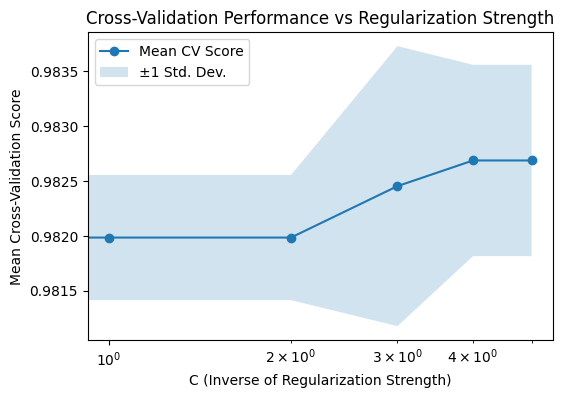

In [221]:
lr_clf = gs_pipeline.best_estimator_

gs_pipeline.cv_results_

def show_cross_validation_results(gs_pipeline):

    #for clase, scores in classifier.scores_.items():
    #    print(f"Clase {clase}: shape {scores.shape}")  # (n_folds, n_Cs)

    #scores = list(classifier.scores_.values())[0]  # si es binario, tomamos la clase positiva
    #mean_scores = np.mean(scores, axis=0)
    #std_scores = np.std(scores, axis=0)

    import matplotlib.pyplot as plt
    mean_scores = gs_pipeline.cv_results_['mean_test_score']
    std_scores = gs_pipeline.cv_results_['std_test_score']

    plt.figure(figsize=(6,4))
    plt.semilogx( mean_scores, marker='o', label='Mean CV Score')
    plt.fill_between(
        np.arange(len(mean_scores)),
        mean_scores - std_scores,
        mean_scores + std_scores,
        alpha=0.2,
        label='±1 Std. Dev.'
    )
    plt.xlabel("C (Inverse of Regularization Strength)")
    plt.ylabel("Mean Cross-Validation Score")
    plt.title("Cross-Validation Performance vs Regularization Strength")
    plt.legend()
    plt.show()


show_cross_validation_results(gs_pipeline)



In [222]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib import pyplot as plt


def show_cv_confusion_matrix(cv_scores, y, threshold=0.5):


    # Calcular la matriz de confusión
    cm = confusion_matrix(y, cv_scores>threshold)

    # Mostrarla
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Matriz de confusión (validación cruzada), th={threshold:.02f}')
    plt.savefig('CV_conf_matrix.png')
    plt.show()

def show_cv_precision_recall(cv_scores, y):
    
    precision, recall, _ = precision_recall_curve(y, cv_scores)
    ap = average_precision_score(y, cv_scores)

    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Cross-validated Precision–Recall Curve")
    plt.legend()
    plt.grid(True, ls='--', alpha=0.6)
    plt.savefig('CV_PR.png')
    plt.show()


def show_cv_roc(cv_scores, y):

    #y_score = model1_pipeline.predict_proba(data1_X)[:, 1]  # probabilidad de la clase positiva
    fpr, tpr, _ = roc_curve(y, cv_scores)
    auc = roc_auc_score(y, cv_scores)

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Cross Validated ROC curve")
    plt.legend()
    plt.savefig('Cross Validated ROC curve')
    plt.show()


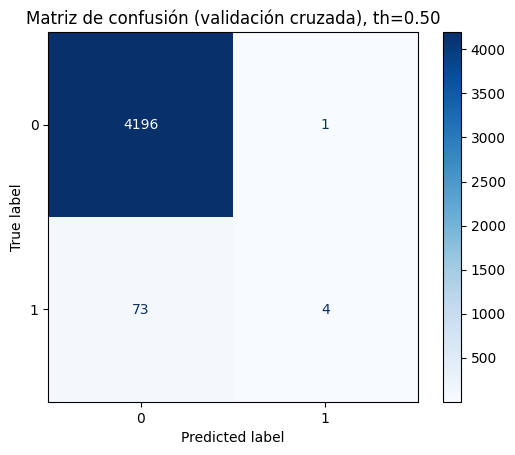

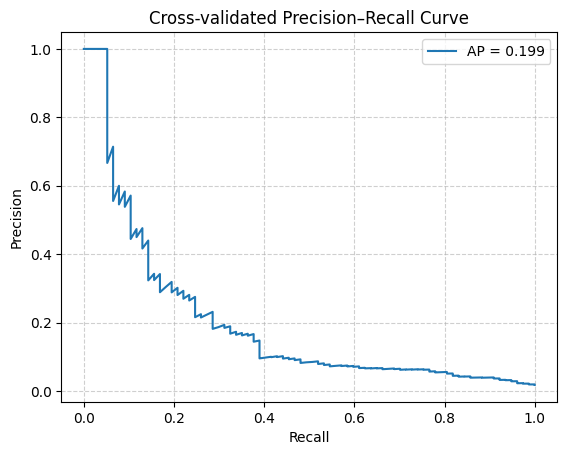

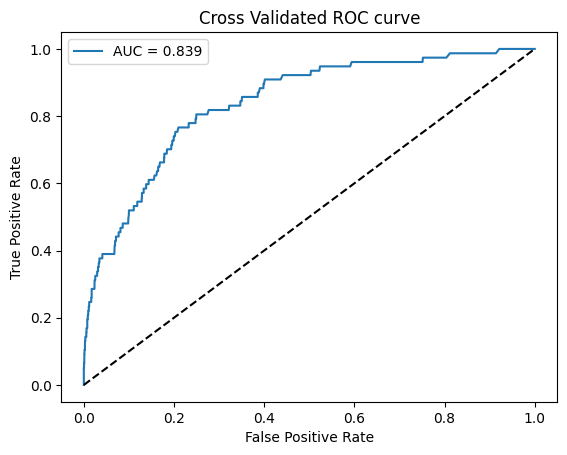

In [223]:
cv_scores = cross_val_predict(gs_pipeline, data1_X, data1_y,
                                cv=5, method='predict_proba')[:, 1]

show_cv_confusion_matrix(cv_scores, data1_y)
show_cv_precision_recall(cv_scores, data1_y)
show_cv_roc(cv_scores,data1_y)

In [224]:
gs_pipeline.best_estimator_.score(data1_X, data1_y)

0.9829199812821713

In [226]:
gs_pipeline.score(data1_X, data1_y)

0.9829199812821713

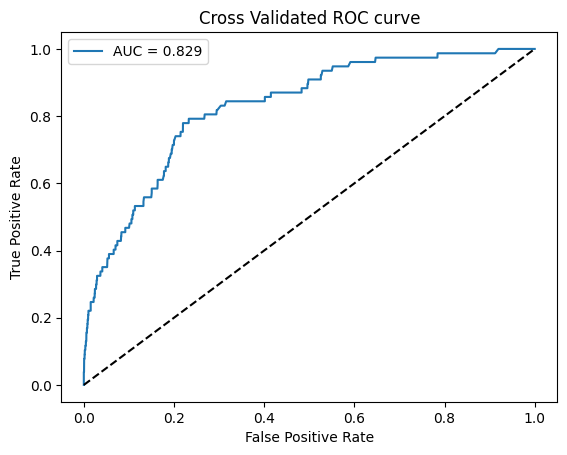

In [138]:
import numpy as np
odds_ratios = np.exp(model1_pipeline['classifier'].coef_)


In [139]:
odds_ratios

array([[2.78908488, 0.94742373, 1.55646614, 0.66262677, 0.90411981,
        1.08701694, 0.99563803, 0.99859443, 0.86779139, 5.70567065,
        0.45942872, 0.5634924 , 0.76531856, 0.99605297, 3.11729653]])

In [140]:
params = model1_pipeline['classifier'].get_params()
params

{'Cs': 10,
 'class_weight': None,
 'cv': 5,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1.0,
 'l1_ratios': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'refit': True,
 'scoring': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0}

In [141]:
model1_pipeline['preprocessing'].get_feature_names_out()

array(['num__Grupo_edad', 'cat__IAEprevio_corregido_NO',
       'cat__IAEprevio_corregido_NO SE INDICA',
       'cat__IAEprevio_corregido_SI', 'cat__EnTratamiento_NO',
       'cat__EnTratamiento_SI', 'cat__EnTratamiento_Sin dato',
       'cat__EnTratamiento_Tratamiento en el prestador habitual',
       'cat__MetodoIAEPrevio_Ahorcamiento o asfixia',
       'cat__MetodoIAEPrevio_Arma de fuego',
       'cat__MetodoIAEPrevio_Ingesta de Medicamentos',
       'cat__MetodoIAEPrevio_Lesiones autoinfligidas',
       'cat__MetodoIAEPrevio_Otros', 'cat__MetodoIAEPrevio_otros',
       'remainder__Sexo'], dtype=object)

In [142]:
model1_pipeline['classifier'].coef_

array([[ 1.02571354e+00, -5.40088390e-02,  4.42417958e-01,
        -4.11543387e-01, -1.00793395e-01,  8.34371940e-02,
        -4.37151130e-03, -1.40655522e-03, -1.41803923e-01,
         1.74146053e+00, -7.77771483e-01, -5.73601441e-01,
        -2.67463108e-01, -3.95484405e-03,  1.13696613e+00]])

In [143]:
coef_df = pd.DataFrame(
    model1_pipeline['classifier'].coef_.T,  # transponemos para alinear cada feature
    index=model1_pipeline['preprocessing'].get_feature_names_out(),
    #columns=model1_pipeline['classifier'].classes_  # una columna por clase
)

In [144]:
coef_df

,0
num__Grupo_edad,1.025714
cat__IAEprevio_corregido_NO,-0.054009
cat__IAEprevio_corregido_NO SE INDICA,0.442418
cat__IAEprevio_corregido_SI,-0.411543
cat__EnTratamiento_NO,-0.100793
cat__EnTratamiento_SI,0.083437
cat__EnTratamiento_Sin dato,-0.004372
cat__EnTratamiento_Tratamiento en el prestador habitual,-0.001407
cat__MetodoIAEPrevio_Ahorcamiento o asfixia,-0.141804
cat__MetodoIAEPrevio_Arma de fuego,1.741461


In [145]:
odds_ratios_df = pd.DataFrame(
    odds_ratios.T,  # transponemos para alinear cada feature
    index=model1_pipeline['preprocessing'].get_feature_names_out(),
    #columns=model1_pipeline['classifier'].classes_  # una columna por clase
)

In [146]:
odds_ratios_df

,0
num__Grupo_edad,2.789085
cat__IAEprevio_corregido_NO,0.947424
cat__IAEprevio_corregido_NO SE INDICA,1.556466
cat__IAEprevio_corregido_SI,0.662627
cat__EnTratamiento_NO,0.904120
cat__EnTratamiento_SI,1.087017
cat__EnTratamiento_Sin dato,0.995638
cat__EnTratamiento_Tratamiento en el prestador habitual,0.998594
cat__MetodoIAEPrevio_Ahorcamiento o asfixia,0.867791
cat__MetodoIAEPrevio_Arma de fuego,5.705671


In [295]:
df_features_sin_dup["IAEprevio_corregido"].value_counts()

IAEprevio_corregido
SI              2123
NO              1482
NO SE INDICA     669
Name: count, dtype: int64

In [282]:
data1_y.unique()

array([False,  True])

In [283]:
data1_X=data1[["Grupo_edad","Sexo", "IAEprevio_corregido","EnTratamiento", "MetodoIAEMasFrecuente"]]
data1_y = data1['Motivo_externo']=='Suicidio'

NameError: name 'data1' is not defined

Motivo_externo
True     33
False    29
Name: count, dtype: int64

In [99]:
df_IAE2023['PrestadorRecod'].value_counts()

PrestadorRecod
MEDICA URUGUAYA MUCAM                         355
CASMU                                         240
UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA    231
CIRCULO CATOLICO DE OBREROS DEL URUGUAY       196
ASSE - MALDONADO                              162
                                             ... 
ASSE - PAYSANDU QUEBRACHO                       1
ASSE - FRANCISCO SOCA                           1
MUCAM - ASSE - SD                               1
PARTICULAR                                      1
ASSE - DURAZNO SARANDI DEL YI                   1
Name: count, Length: 426, dtype: int64

In [100]:
df_Mort2023['Motivoexterno'].value_counts()

Motivoexterno
No corresponde    31951
Accidente          1084
Suicidio            763
Homicidio           391
Se desconoce        207
Otro                  3
Name: count, dtype: int64